# 139. Word Break

Given a string s and a dictionary of strings wordDict, return true if s can be segmented into a space-separated sequence of one or more dictionary words.

Note that the same word in the dictionary may be reused multiple times in the segmentation.

 
## Example 1:

Input: s = "leetcode", wordDict = ["leet","code"]
Output: true
Explanation: Return true because "leetcode" can be segmented as "leet code".

## Example 2:

Input: s = "applepenapple", wordDict = ["apple","pen"]
Output: true
Explanation: Return true because "applepenapple" can be segmented as "apple pen apple".
Note that you are allowed to reuse a dictionary word.

## Example 3:

Input: s = "catsandog", wordDict = ["cats","dog","sand","and","cat"]
Output: false

1️⃣ #Specification


Dado uma string s, precisamos verificar se ela pode ser segmentada em substrings válidas presentes em wordDict.
O problema é essencialmente verificar se existe uma partição válida da string, podendo reutilizar palavras, com restrição de cobertura total.

## Edge Cases & Traps
    s = "" → geralmente True (string vazia é válida)
    Palavras reutilizáveis infinitamente (ex: "aaaaaaa")
    Prefixos válidos mas sufixo inválido → falso positivo comum
    wordDict grande → precisa otimizar lookup (set)
    Substrings repetidas → sem memo vira exponencial

# Plan

Tentar todas as prefix + suffix possíveis:

"leetcode"
(l) + (eetcode)
(le) + (etcode)
(lee) + (tcode)
...

Para cada split, verificar recursivamente
Explosão exponencial: O(2^N)

## Heurística Dynamic Programming (Bottom-Up)

Definição do estado

dp[i] = True se s[0:i] pode ser segmentada

Transição

dp[i] = True se existir j < i tal que:
    dp[j] == True AND s[j:i] a palavras existe em nosso dicionary de palavras

## Desenho:

s = "leetcode"

wordDict = ["leet", "code"]

Inicialização

dp = [T, F, F, F, F, F, F, F, F]
      0  1  2  3  4  5  6  7  8

 dp[0] = True (base)

Iteração

i = 4 s[0:4] = "leet" ∈ dict
dp[4] = True

dp = [T, F, F, F, T, F, F, F, F]

i = 8

s[4:8] = "code" ∈ dict AND dp[4] = True

dp[8] = True

dp = [T, F, F, F, T, F, F, F, T]
 Insight

Você não está quebrando a string — você está validando prefixos válidos acumulados.

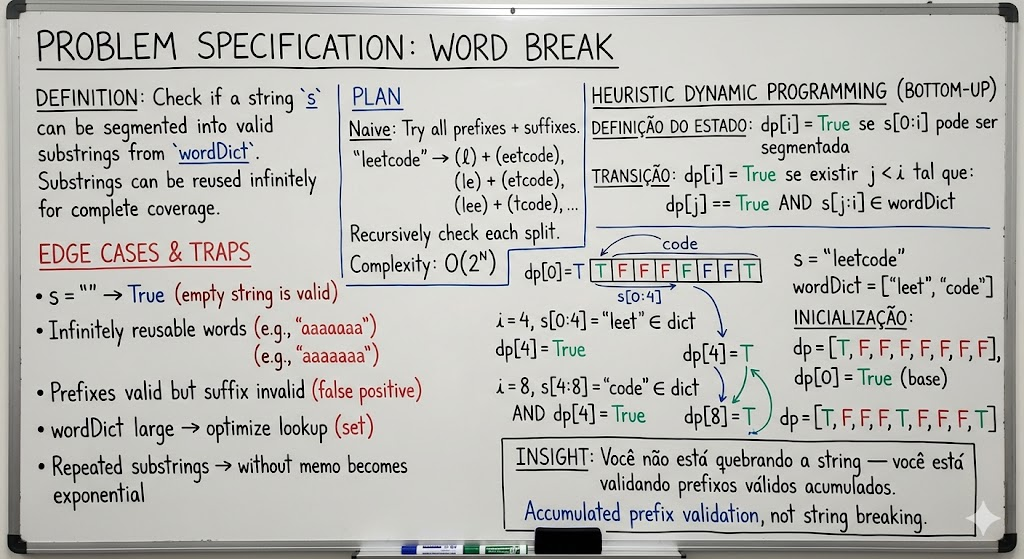

In [ ]:
from typing import List


class Solution:
    def wordBreak(self, s: str, wordDict: List[str]) -> bool:
        word_set = set(wordDict)  # O(1) lookup

        n = len(s)
        dp = [False] * (n + 1)

        dp[0] = True  # string vazia é válida

        for i in range(1, n + 1):  # percorre fim do prefixo # O(N)
            for j in range(i):     # tenta todos os cortes # O(N)

                # se prefixo até j é válido
                # e substring j:i está no dicionário
                if dp[j] and s[j:i] in word_set:
                    dp[i] = True
                    break   
                
        return dp[-1]